In [11]:
import sys
!{sys.executable} -m pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   --------------- ------------------------ 3.1/8.1 MB 20.5 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 21.9 MB/s eta 0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 21.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   -------------------------------- ------- 5.8/7.0 MB 27.0 MB/s eta 0:00:01
   ---------------------------------------- 7.0/7.0 MB 20.6 MB/s eta 0:00:00


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Load curated ward-level dataset
df = pd.read_csv("curated_metrics_by_ward.csv")

df.head()

,Ward,Total_Segments,Avg_Pavement_Rating,Pct_Poor_Segments,Citywide_Hydrant_Count
0,0,166,6.012048,21.084337,5625
1,1,456,7.048246,4.166667,5625
2,2,432,6.523148,9.490741,5625
3,3,376,7.250000,6.117021,5625
4,4,502,6.442231,6.772908,5625


## Ward-Level Infrastructure Metrics

The following analysis uses the curated ward-level dataset generated from the working prototype pipeline. Metrics include:
- Total street segments
- Average pavement rating
- Percent of poorly rated segments (rating ≤ 4)
- Citywide hydrant count (contextual reference)

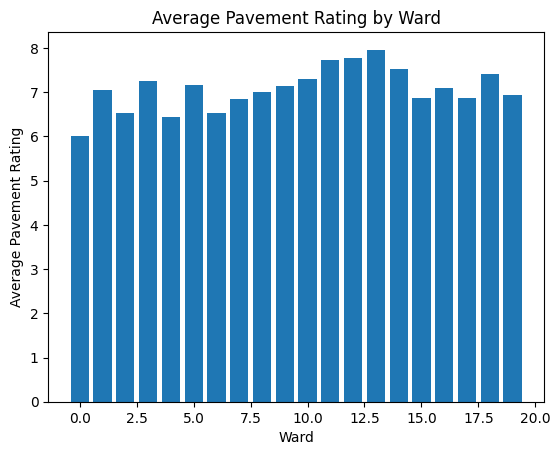

In [20]:
# Average Pavement Rating by Ward
plt.figure()
plt.bar(df["Ward"], df["Avg_Pavement_Rating"])
plt.xlabel("Ward")
plt.ylabel("Average Pavement Rating")
plt.title("Average Pavement Rating by Ward")
plt.show()

Average pavement ratings vary across wards, indicating localized differences in street condition. While most wards cluster within a similar range, some show noticeably lower averages, suggesting potential areas for closer inspection or resource prioritization.

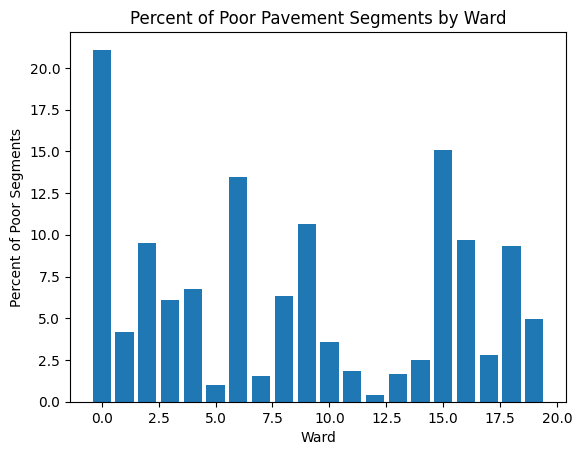

In [23]:
# Percent of Poor Segments
plt.figure()
plt.bar(df["Ward"], df["Pct_Poor_Segments"])
plt.xlabel("Ward")
plt.ylabel("Percent of Poor Segments")
plt.title("Percent of Poor Pavement Segments by Ward")
plt.show()

The percentage of poorly rated segments (rating ≤ 4) varies meaningfully across wards. This metric highlights concentration rather than average condition and may reveal areas where deteriorated segments are clustered.

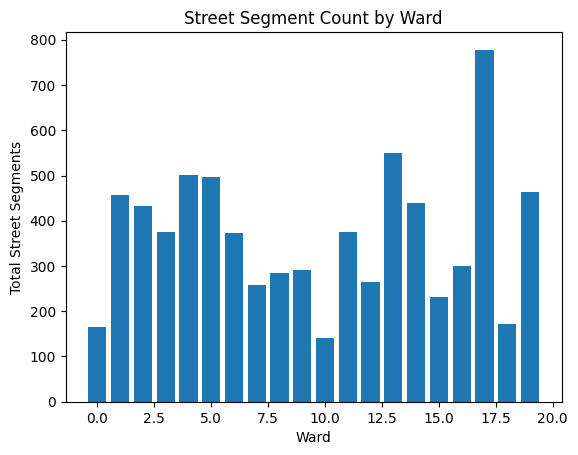

In [21]:
# Street Segment Count by Ward
plt.figure()
plt.bar(df["Ward"], df["Total_Segments"])
plt.xlabel("Ward")
plt.ylabel("Total Street Segments")
plt.title("Street Segment Count by Ward")
plt.show()

This plot explores whether lower average pavement ratings correspond to higher shares of poorly rated segments. A relationship here would indicate structural rather than random deterioration patterns.

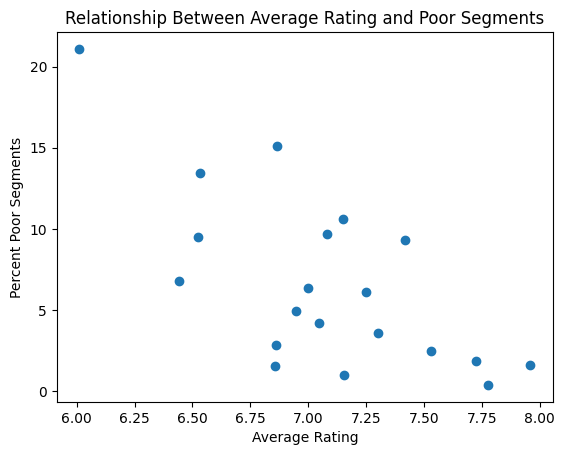

In [ ]:
# Scatter: Avg Rating vs % Poor
# Shows whether wards with worse averages also have more failing streets.
plt.figure()
plt.scatter(df["Avg_Pavement_Rating"], df["Pct_Poor_Segments"])
plt.xlabel("Average Rating")
plt.ylabel("Percent Poor Segments")
plt.title("Relationship Between Average Rating and Poor Segments")
plt.show()

This plot explores whether lower average pavement ratings correspond to higher shares of poorly rated segments. A relationship here would indicate structural rather than random deterioration patterns.

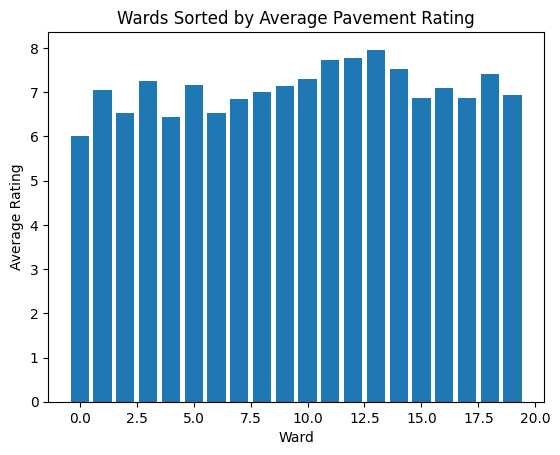

In [ ]:
# Wards Ranked by Average Condition
# Makes best vs worst areas immediately visible.
sorted_df = df.sort_values("Avg_Pavement_Rating")
plt.figure()
plt.bar(sorted_df["Ward"], sorted_df["Avg_Pavement_Rating"])
plt.xlabel("Ward")
plt.ylabel("Average Rating")
plt.title("Wards Sorted by Average Pavement Rating")
plt.show()

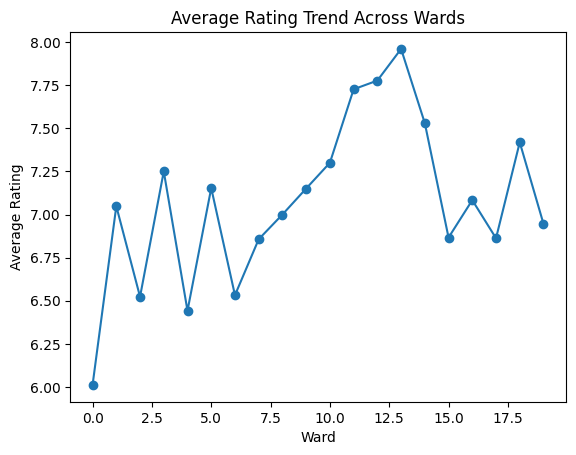

In [ ]:
# Trend Across Wards
# Shows variation across administrative units.
plt.figure()
plt.plot(df["Ward"], df["Avg_Pavement_Rating"], marker="o")
plt.xlabel("Ward")
plt.ylabel("Average Rating")
plt.title("Average Rating Trend Across Wards")
plt.show()

In [ ]:
# Distribution of Ward Ratings
# Are wards mostly similar or very different?
plt.figure()
plt.hist(df["Avg_Pavement_Rating"], bins=10)
plt.xlabel("Average Rating")
plt.ylabel("Frequency")
plt.title("Distribution of Ward Average Ratings")
plt.show()

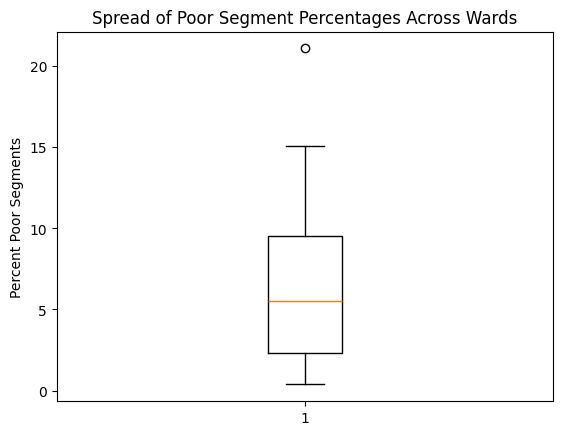

In [30]:
# Spread of Poor Segment Percentages
# Shows variability and outliers.

plt.figure()
plt.boxplot(df["Pct_Poor_Segments"])
plt.ylabel("Percent Poor Segments")
plt.title("Spread of Poor Segment Percentages Across Wards")
plt.show()

In [32]:
# Top 5 Best (highest avg rating)
top5 = df.sort_values("Avg_Pavement_Rating", ascending=False).head(5)

# Top 5 Worst (lowest avg rating)
bottom5 = df.sort_values("Avg_Pavement_Rating", ascending=True).head(5)

# Combine for comparison table
comparison = pd.concat([
    top5.assign(Category="Top 5 Best"),
    bottom5.assign(Category="Top 5 Worst")
])

comparison

,Ward,Total_Segments,Avg_Pavement_Rating,Pct_Poor_Segments,Citywide_Hydrant_Count,Category
13,13,550,7.960000,1.636364,5625,Top 5 Best
12,12,264,7.776515,0.378788,5625,Top 5 Best
11,11,376,7.726064,1.861702,5625,Top 5 Best
14,14,440,7.529545,2.500000,5625,Top 5 Best
18,18,172,7.418605,9.302326,5625,Top 5 Best
0,0,166,6.012048,21.084337,5625,Top 5 Worst
4,4,502,6.442231,6.772908,5625,Top 5 Worst
2,2,432,6.523148,9.490741,5625,Top 5 Worst
6,6,372,6.532258,13.440860,5625,Top 5 Worst
7,7,258,6.856589,1.550388,5625,Top 5 Worst


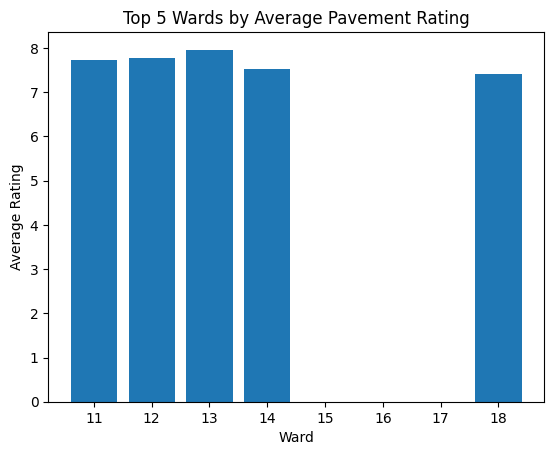

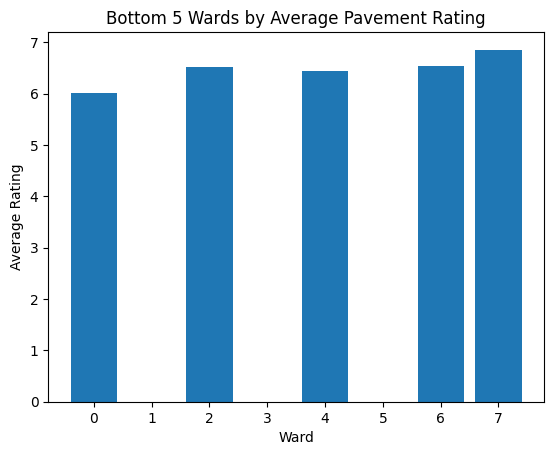

In [33]:
# Visualization: Best vs Worst Comparison

plt.figure()
plt.bar(top5["Ward"], top5["Avg_Pavement_Rating"])
plt.xlabel("Ward")
plt.ylabel("Average Rating")
plt.title("Top 5 Wards by Average Pavement Rating")
plt.show()

plt.figure()
plt.bar(bottom5["Ward"], bottom5["Avg_Pavement_Rating"])
plt.xlabel("Ward")
plt.ylabel("Average Rating")
plt.title("Bottom 5 Wards by Average Pavement Rating")
plt.show()

## Top and Bottom Performing Wards (Average Pavement Condition)

To better understand variation across the city, the wards were ranked by average pavement rating. The top five and bottom five wards are displayed below for comparison.

### Interpretation

The ranking highlights meaningful variation in pavement condition across wards.

- The top-performing wards show consistently high average ratings and very low percentages of poorly rated segments.
- The bottom-performing wards exhibit lower averages and, in some cases, substantially higher shares of deteriorated segments.

This contrast suggests that pavement condition is not uniformly distributed across the city and may warrant targeted maintenance prioritization.

Importantly, these results are descriptive and do not imply causation. Further investigation would be required to determine contributing factors.

In [35]:
df.describe()

,Ward,Total_Segments,Avg_Pavement_Rating,Pct_Poor_Segments,Citywide_Hydrant_Count
count,20.00000,20.000000,20.000000,20.000000,20.0
mean,9.50000,367.500000,7.071873,6.618680,5625.0
std,5.91608,154.240926,0.481533,5.436344,0.0
min,0.00000,140.000000,6.012048,0.378788,5625.0
25%,4.75000,262.500000,6.860998,2.340426,5625.0
50%,9.50000,374.000000,7.065789,5.536959,5625.0
75%,14.25000,458.000000,7.329651,9.534722,5625.0
max,19.00000,778.000000,7.960000,21.084337,5625.0


### Summary Statistics

Descriptive statistics confirm that ratings fall within expected bounds and that ward-level variation is present across multiple metrics.